In [ ]:
"""
Sample inference script for Phi-4-Vision-5B.
"""

import os
import torch
from transformers import AutoModelForCausalLM, AutoProcessor
from PIL import Image

device = "cuda:1"

## LOAD MODEL AND PROCESSOR FROM CURRENT DIRECTORY
model_path = os.path.dirname(os.path.abspath("__file__"))

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map=device,
    use_flash_attention_2=True,
    trust_remote_code=True,
)

processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

print(f"Model loaded on {model.device}")

In [ ]:
## PLOT IMAGE WITH MODEL PREDICTION AND GROUND TRUTH

import ast

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_boxes(image, model_output, correct_answer_norm):

    # Parse model output
    model_bbox = ast.literal_eval(model_output)  # [x1, y1, x2, y2] normalized

    # Convert normalized coords to absolute pixel coords
    img_w, img_h = image.size

    model_abs = [
        model_bbox[0] * img_w, model_bbox[1] * img_h,
        (model_bbox[2] - model_bbox[0]) * img_w, (model_bbox[3] - model_bbox[1]) * img_h
    ]  # x, y, w, h in pixels

    correct_abs = [
        correct_answer_norm[0] * img_w, correct_answer_norm[1] * img_h,
        (correct_answer_norm[2] - correct_answer_norm[0]) * img_w, (correct_answer_norm[3] - correct_answer_norm[1]) * img_h
    ]  # x, y, w, h in pixels

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(image)

    # Draw model prediction (red)
    rect_model = patches.Rectangle(
        (model_abs[0], model_abs[1]), model_abs[2], model_abs[3],
        linewidth=3, edgecolor='red', facecolor='none', linestyle='-', label='Model Prediction'
    )
    ax.add_patch(rect_model)

    # Draw correct answer (green)
    rect_correct = patches.Rectangle(
        (correct_abs[0], correct_abs[1]), correct_abs[2], correct_abs[3],
        linewidth=3, edgecolor='lime', facecolor='none', linestyle='--', label='Ground Truth'
    )
    ax.add_patch(rect_correct)

    ax.legend(fontsize=12, loc='upper right')
    ax.set_title(f"Model: {model_output}  |  GT: [{correct_answer_norm[0]:.3f}, {correct_answer_norm[1]:.3f}, {correct_answer_norm[2]:.3f}, {correct_answer_norm[3]:.3f}]", fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
def run_inference(processor, model, prompt, image, thinking_mode="hybrid"):
    ## FORM MESSAGE AND LOAD IMAGE
    messages = [
        {
            "role": "user", 
            "content": prompt,
        }
    ]

    ## PROCESS INPUTS 

    prompt = processor.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        return_dict=False,
    )

    if thinking_mode == "think":
        prompt = str(prompt) + "<think>"
    elif thinking_mode == "nothink":
        prompt = str(prompt) + "<|dummy_84|>"

    print(f"Prompt: {prompt}")

    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(model.device)

    ## GENERATE RESPONSE
    output_ids = model.generate(
        **inputs,
        max_new_tokens=1024,
        temperature=None,
        top_p=None,
        do_sample=False,
    )

    ## DECODE RESPONSE
    sequence_length = inputs["input_ids"].shape[1]

    sequence_length -= 1 if thinking_mode == "think" else 0 # remove the extra token for nothink mode

    new_output_ids = output_ids[:, sequence_length:]
    model_output = processor.batch_decode(
        new_output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    return model_output

Loading image from /datadisk/checkpoints/Phi-4-reasoning-vision-15B-bxp9x/pc_0c634288-11b9-498f-8fb6-582e26ea17c9.png
Prompt: <|im_start|>system<|im_sep|>You are Phi, a multimodal model trained by Microsoft to help users.  Your role as an assistant is to provide accurate, coherent, and actionable responses, adapting your reasoning mode (\"NOTHINK\" vs \"THINK\") automatically based on the complexity, clarity, and confidence of each task.\n\n#### NOTHINK Mode\nUse this mode when the task is clear, factual, low-complexity, or can be confidently answered immediately without iterative reasoning. Such as when the input is clear and unambiguous or visual recognition or text comprehension is straightforward, and where a factual, numeric, or short procedural answer is sufficient. Provide a concise, accurate, and confident answer. Please structure your response into one section: using the specified format: <|dummy_84|> {Solution section}. In the Solution section, present the final solution that

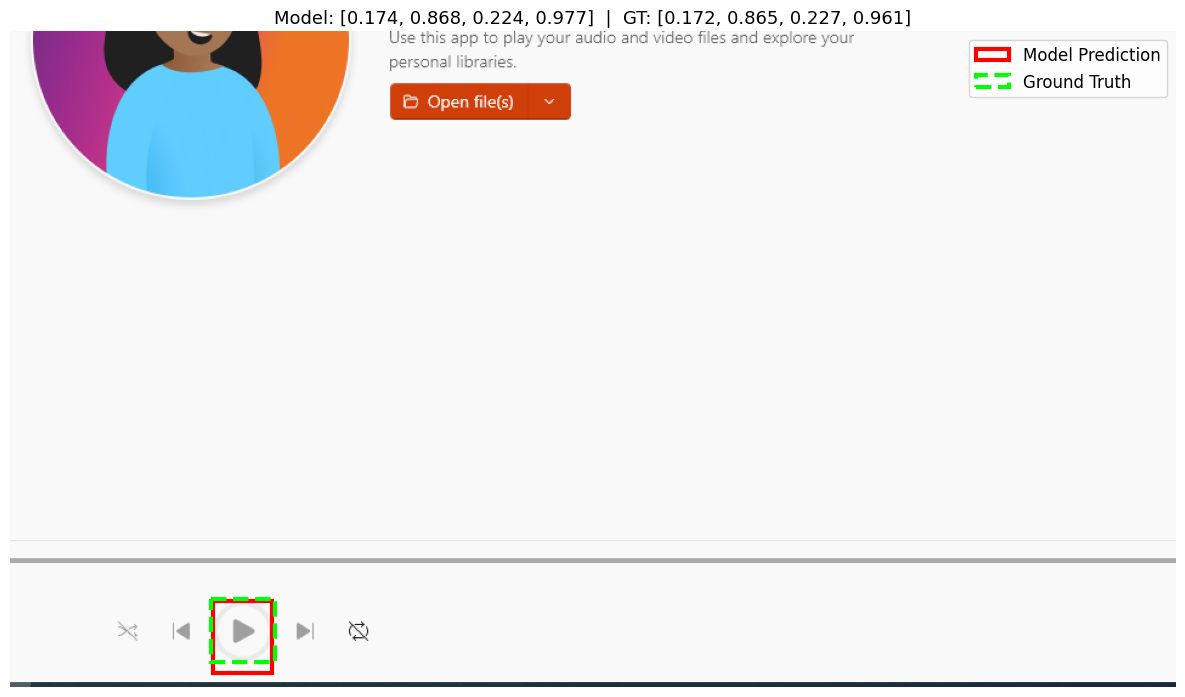

In [32]:
### GROUNDING EXAMPLE

prompt = "<image>\nLocate the the UI element this instruction describes: start playback. Output its bbox coordinates using the format of [x1, y1, x2, y2] using relative coordinates from 0.0000 to 1.0000."
image_file = "pc_0c634288-11b9-498f-8fb6-582e26ea17c9.png"

image_path = os.path.join(model_path, image_file)
print(f"Loading image from {image_path}")
image = Image.open(image_path).convert("RGB")

model_output = run_inference(processor, model, prompt, image, thinking_mode="hybrid")

correct_answer = [165,467,53,52] # in xywh format, absolute coordinates

print(f'Response: {model_output}')
print("Expected Answer: [0.174, 0.868, 0.224, 0.977]")

correct_answer_norm = [
    correct_answer[0]/image.size[0],
    correct_answer[1]/image.size[1],
    (correct_answer[0]+correct_answer[2])/image.size[0],
    (correct_answer[1]+correct_answer[3])/image.size[1],
] # convert to normalized xyxy format

print(f"Correct Answer: {correct_answer_norm}")

plot_boxes(image, model_output, correct_answer_norm)

In [ ]:
### DESCRIPTION EXAMPLE
prompt = "<image>\nDescribe this image in detail."
image_file = "000a045a0715d64d.jpg"

### GROUNDING EXAMPLE
image_path = os.path.join(model_path, image_file)
print(f"Loading image from {image_path}")
image = Image.open(image_path).convert("RGB")

model_output = run_inference(processor, model, prompt, image, thinking_mode="hybrid")

print(f'Response: {model_output}')


Loading image from /datadisk/checkpoints/Phi-4-reasoning-vision-15B-bxp9x/000a045a0715d64d.jpg
Prompt: <|im_start|>system<|im_sep|>You are Phi, a multimodal model trained by Microsoft to help users.  Your role as an assistant is to provide accurate, coherent, and actionable responses, adapting your reasoning mode (\"NOTHINK\" vs \"THINK\") automatically based on the complexity, clarity, and confidence of each task.\n\n#### NOTHINK Mode\nUse this mode when the task is clear, factual, low-complexity, or can be confidently answered immediately without iterative reasoning. Such as when the input is clear and unambiguous or visual recognition or text comprehension is straightforward, and where a factual, numeric, or short procedural answer is sufficient. Provide a concise, accurate, and confident answer. Please structure your response into one section: using the specified format: <|dummy_84|> {Solution section}. In the Solution section, present the final solution that you deem correct. The 

---

<!-- CO-OP TRANSLATOR DISCLAIMER START -->
**अस्वीकरण**:
इस दस्तावेज़ का अनुवाद AI अनुवाद सेवा [Co-op Translator](https://github.com/Azure/co-op-translator) का उपयोग करके किया गया है। जबकि हम सटीकता के लिए प्रयासरत हैं, कृपया ध्यान दें कि स्वचालित अनुवादों में त्रुटियाँ या गलतियाँ हो सकती हैं। मूल दस्तावेज़ अपनी मूल भाषा में आधिकारिक स्रोत माना जाना चाहिए। महत्वपूर्ण जानकारी के लिए पेशेवर मानव अनुवाद की सलाह दी जाती है। इस अनुवाद के उपयोग से उत्पन्न किसी भी गलतफहमी या गलत व्याख्या के लिए हम जिम्मेदार नहीं हैं।
<!-- CO-OP TRANSLATOR DISCLAIMER END -->
